### Комментарии

Я старался сделать максимально подробный EDA - с помощью которого реально можно понять, как работают эти данные
Если представить, что на месте номеров предметов стоят их реальные названия, графики приобретают более "веселый" вид
Прошу просмотреть все ячейки. Я старался

## Импорт нужных модулей

In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import json
from itertools import combinations
from collections import Counter

## Загрузка данных

In [3]:
def load_data(file_name: str) -> list[list[int]]:
    """
    Загружает данные из JSON-файла, где каждая строка является отдельным JSON-объектом.

    Функция построчно читает файл, парсит каждую непустую строку как JSON
    и добавляет полученный объект в список.

    Args
    ----------
        file_name (str): Путь к JSON-файлу, где каждая строка содержит JSON-массив целых чисел.


    Returns
    ----------
        list[list[int]]: Список сессий, где каждая сессия представлена списком целых чисел.
    """
    sessions = []
    with open(file_name, 'r', encoding='utf-8') as file:
        for line in file:
            line = line.strip()
            if line:
                sessions.append(json.loads(line))
    return sessions

Загрузка сессий

In [4]:
sessions = load_data("sessions.jsonl")

## Начало анализа в Pandas

Формирую датафрейм для дальнейшей обработки и анализа.

In [5]:
sessions_df = pd.DataFrame({
    'session_id': range(len(sessions)),
    'session': sessions,
    'length': [len(s) for s in sessions]
})

Считаю, сколько раз каждый товар повторился во всех сессиях.

In [6]:
items_count = Counter()

Прохожу по каждой сессии в списке sessions.

In [7]:
for session in sessions:
    items_count.update(session)

Преобразую Counter в DataFrame для удобного анализа. 
Устанавливаю айдишник предмета как индекс датафрейма, чтоб не путаться из-за индекса по умолчанию.
И сортирую по новоиспеченному индексу, чтобы все было по канону, как и было, но удобнее


In [8]:
items_count = pd.DataFrame(
    items_count.most_common(), 
    columns=['item', 'count'] 
)

items_count = items_count.set_index('item')

items_count = items_count.sort_values("item")

Смотрю первые строчки датафрейма, чтоб убедиться, что преобразование прошло нормально.

In [9]:
items_count.head()

,count
item,
0,15
1,73
2,81
3,22
4,19


Базовые статистики, метрики по сессиям и номерам товаров.

In [10]:
average_session_length = sessions_df["length"].mean()
max_session_length = sessions_df["length"].max()
min_session_length = sessions_df["length"].min()

max_item_number = max(max(session) for session in sessions)
min_item_number = min(min(session) for session in sessions)

print(f"Всего сессий: {len(sessions)}")
print(f"Первая сессия: {sessions[0]}")
print(f"Последняя сессия: {sessions[-1]}\n")
print(f"Средняя длина сессии - {round(average_session_length, 3)}")
print(f"Макс. длина сессии - {max_session_length}")
print(f"Мин. длина сессии - {min_session_length}\n")
print(f"Максимальное значение номера товара: {max_item_number}")
print(f"Максимальное значение номера товара: {min_item_number}")
print(f"Количество уникальных товаров - {len(items_count)}")

Всего сессий: 2565
Первая сессия: [380, 293, 262, 114, 123, 345, 335, 245, 272, 293, 233, 302, 247, 290, 260, 341, 293]
Последняя сессия: [114, 335, 53, 54, 114, 395, 65, 247, 48, 233, 361, 250, 41, 302, 54, 293, 65, 335, 385, 65]

Средняя длина сессии - 10.465
Макс. длина сессии - 20
Мин. длина сессии - 3

Максимальное значение номера товара: 399
Максимальное значение номера товара: 0
Количество уникальных товаров - 400


Проанализирую частоту предметов.

Сортирую по убыванию предметы, согласно их частотам.

In [11]:
items_count_sorted = items_count.sort_values(items_count.columns[0], ascending=False)

Считаю самые базовые характеристики

In [12]:
mean_frequence = items_count_sorted.iloc[:, 0].mean()
median_frequence = items_count_sorted.iloc[:, 0].median()
max_frequence = items_count_sorted.iloc[0, 0]
min_frequence = items_count_sorted.iloc[-1, 0]
index_max_frequence = items_count_sorted.index[0]
index_min_frequence = list(items_count_sorted.index[[-2, -1]])
std = items_count_sorted.iloc[:, 0].std()

print("Подсчет всех частот, учитывая повторения в сессиях:\n")
print(f"Средняя частота: {mean_frequence:.3f} раз")
print(f"Медианная частота: {median_frequence:.3f} раз")
print(f"Максимальная частота: {max_frequence} раз (предмет: {index_max_frequence})")
print(f"Минимальная частота: {min_frequence} раз (предметы: {index_min_frequence})")
print(f"Стандартное отклонение: {std:.3f}")

Подсчет всех частот, учитывая повторения в сессиях:

Средняя частота: 67.108 раз
Медианная частота: 22.000 раз
Максимальная частота: 2914 раз (предмет: 54)
Минимальная частота: 5 раз (предметы: [184, 305])
Стандартное отклонение: 202.234


## Анализ самых популярных и редких предметов.

Отображаю на графике самые частые и редкие предметы в сессиях 

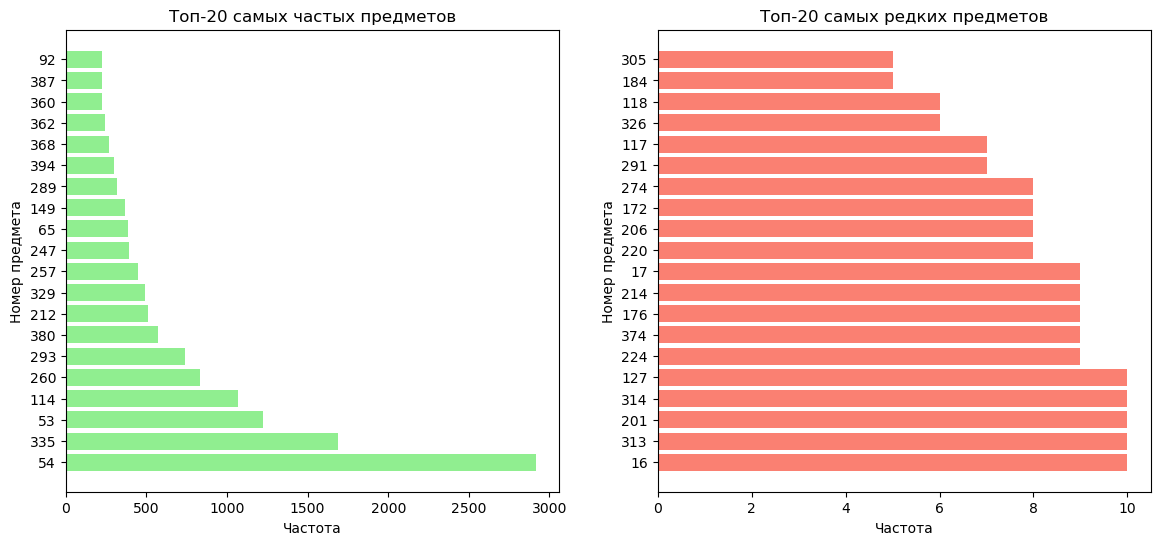

In [13]:
# 20 самых частых предметов.
top20_items = items_count_sorted.head(20)
# 20 самых редких предметов.
bottom20_items = items_count_sorted.tail(20)

# Создаю два горизонтальных столбчатых графика на одной фигуре для наглядного отображения. 
fig, (top_items_ax, bottom_items_ax) = plt.subplots(1, 2, figsize=(14, 6))

# Рисую два аналагоичных графика.
top_items_ax.barh(range(len(top20_items)), top20_items["count"], color="lightgreen")
top_items_ax.set_yticks(range(len(top20_items)))
top_items_ax.set_yticklabels(top20_items.index)
top_items_ax.set_title("Топ-20 самых частых предметов")
top_items_ax.set_xlabel("Частота")
top_items_ax.set_ylabel("Номер предмета");
# Топ редких предметов
bottom_items_ax.barh(range(len(bottom20_items)), bottom20_items["count"], color="salmon")
bottom_items_ax.set_yticks(range(len(bottom20_items)))
bottom_items_ax.set_yticklabels(bottom20_items.index)
bottom_items_ax.set_title("Топ-20 самых редких предметов")
bottom_items_ax.set_xlabel("Частота")
bottom_items_ax.set_ylabel("Номер предмета");

#### Вывод
Самый популярный товар - 54, который оторвался далеко от других. В целом, сильно популярны товары также - 335, 54, 114, 260, 293.
Остальные распределены в меньших масштабах.

Менее популярные товары - 305, 184 в размере 5 штук на все сессии.

## Гистограмма распределения частот
Строю гистограммы, показывающие как распределены частоты в целом.

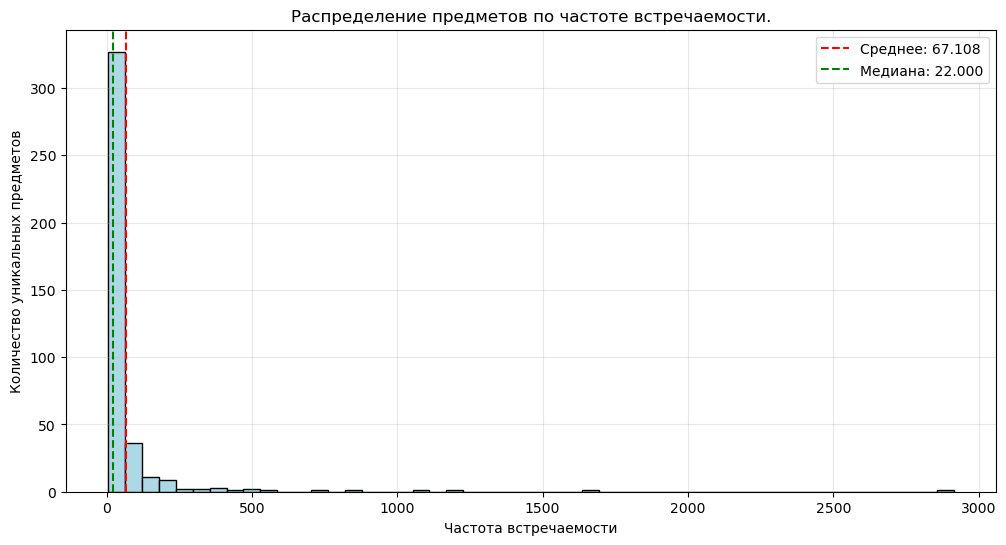

In [14]:
fig, ax = plt.subplots(figsize=(12, 6))

# Гистограмма распределения частот
ax.hist(items_count_sorted.iloc[:, 0].values, bins=50, edgecolor='black', color='lightblue')
ax.set_xlabel("Частота встречаемости")
ax.set_ylabel("Количество уникальных предметов")
ax.set_title("Распределение предметов по частоте встречаемости.")

# Исправляю отображение количества предметов (по умолчанию 10^n)
ax.ticklabel_format(axis="both", style="plain", useOffset=False)
ax.grid(True, alpha=0.3)

# Добавляю пунктирные линии, показывающие среднее, медиану
ax.axvline(mean_frequence, color="red", linestyle='--', label=f"Среднее: {mean_frequence:.3f}")
ax.axvline(median_frequence, color="green", linestyle='--', label=f"Медиана: {median_frequence:.3f}")
ax.legend();

#### Вывод
Отсюда видно, что большинство предметов - около 350 встречаются до 60-70 раз. Есть заметные выбросы, которые были видны на графиках ранее.

## Анализ предметов, которые появлялись в сессии первыми и последними.

In [15]:
# Считаю первые и последние предметы.
first_items = Counter()
last_items = Counter()

for session in sessions:
    first_items[session[0]] += 1
    last_items[session[-1]] += 1

Отображаю на графике данные товары

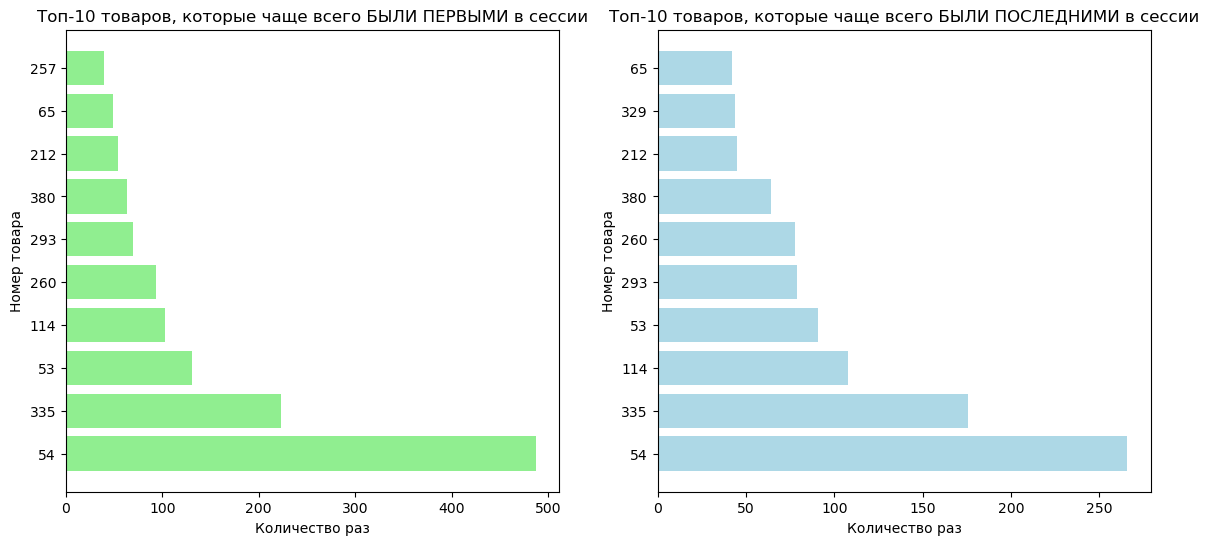

In [16]:
# Топ-10 первых и последних предметов
top10_first = first_items.most_common(10)
top10_last = last_items.most_common(10)

# Создаю два горизонтальных столбчатых графика на одной фигуре
fig, (first_items_ax, last_items_ax) = plt.subplots(1, 2, figsize=(14, 6))

# График для ПЕРВЫХ предмтов в сессии
first_items_list = [item for item, count in top10_first]
first_counts_list = [count for item, count in top10_first]
first_items_ax.barh(range(len(top10_first)), first_counts_list, color="lightgreen")
first_items_ax.set_yticks(range(len(top10_first)))
first_items_ax.set_yticklabels(first_items_list)
first_items_ax.set_title("Топ-10 товаров, которые чаще всего БЫЛИ ПЕРВЫМИ в сессии")
first_items_ax.set_xlabel("Количество раз")
first_items_ax.set_ylabel("Номер товара")

# График для последних товаров
last_items_list = [item for item, count in top10_last]
last_counts_list = [count for item, count in top10_last]

last_items_ax.barh(range(len(top10_last)), last_counts_list, color="lightblue")
last_items_ax.set_yticks(range(len(top10_last)))
last_items_ax.set_yticklabels(last_items_list)
last_items_ax.set_title("Топ-10 товаров, которые чаще всего БЫЛИ ПОСЛЕДНИМИ в сессии")
last_items_ax.set_xlabel("Количество раз")
last_items_ax.set_ylabel("Номер товара");

Отображаю общую статистику появлений по товарам.

In [17]:
print(f"\nВсего сессий: {len(sessions)}")
print(f"Уникальных первых товаров: {len(first_items)}")
print(f"Уникальных последних товаров: {len(last_items)}")
print(f"Уникальных товаров, которые не были первыми: {400 - len(first_items)}")
print(f"Уникальных товаров, которые не были последними и их вообще не купили ни разу: {400 - len(last_items)}\n")


Всего сессий: 2565
Уникальных первых товаров: 312
Уникальных последних товаров: 339
Уникальных товаров, которые не были первыми: 88
Уникальных товаров, которые не были последними и их вообще не купили ни разу: 61



#### Вывод
Предмет 54 самый популярный и здесь - встречается и в начале, и в конце чаще всего. В топе в обоих графиках - 335, 114, 260, 293, 53.
В целом, данный график прямопропорционально связан с графиком популярности - чем товар чаще появляется в целом - тем чаще и первым (последним).

## Анализ длин сессий

Для того, чтобы понять, как долго пользователь взаимодействует с лентой товаров.

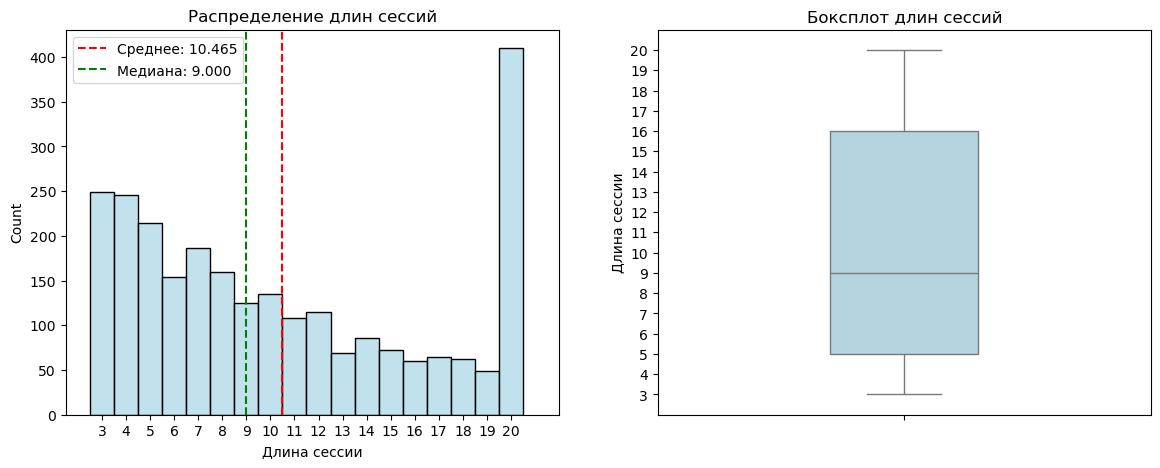

In [18]:
session_lengths = [len(session) for session in sessions]

# Возможные значения
possible_values = list(range(3, 21))

fig, (ax_hist, ax_box) = plt.subplots(1, 2, figsize=(14, 5))

# Гистограмма с дискретными бинами.
sns.histplot(session_lengths, bins=range(2, 22), discrete=True, ax=ax_hist, 
             color="lightblue", edgecolor="black")
ax_hist.axvline(np.mean(session_lengths), color="red", linestyle='--', 
                label=f'Среднее: {np.mean(session_lengths):.3f}')
ax_hist.axvline(np.median(session_lengths), color="green", linestyle='--', 
                label=f'Медиана: {np.median(session_lengths):.3f}')
ax_hist.legend()
ax_hist.set_title("Распределение длин сессий")
ax_hist.set_xlabel("Длина сессии")
ax_hist.set_xticks(range(3, 21))  # Отмечаю все возможные значения
ax_hist.set_xlim(1.5, 22)       # Границы для лучшего отображения

# Боксплот
sns.boxplot(y=session_lengths, ax=ax_box, color="lightblue", width=0.3)
ax_box.set_title("Боксплот длин сессий")
ax_box.set_ylabel("Длина сессии")
ax_box.set_ylim(2, 21)
ax_box.set_yticks(range(3, 21));

#### Вывод
Самая популярная длина сессии - 20. Но в среднем, пользователи просматривают около 10 товаров перед окончательным решением.
Также сессия заканчивается быстро - через 3 просмотра в около 250 случаев (около 10 процентов от всех).

Боксплот показывает распределение по перцентилям. Отсюда понимаем, что 25 процентов сессий - меньше 5, еще 25 процентов - больше 16, а 50 процентов данных - от 5 до 16.

## Анализ паттернов в поведении.

Здесь хочу понять - есть ли в поведении пользователей паттерны.
Паттерн показывает, какой товар обычно открывают после просмотра текущего.

In [19]:
# Завожу счетчик для всех подпоследовательностей каждой сессии
all_subsequences = Counter()

for session in sessions:
    # Перебираю все длины подпоследовательности
    for length in range(2, min(len(session), 20) + 1):
        for idx in range(len(session) - length + 1):
            subseq = tuple(session[idx:idx + length])
            all_subsequences[subseq] += 1

Топ-10 самых частых паттернов 

In [20]:
print("Топ-10 самых частых паттернов поведения юзеров:")
for subseq, count in all_subsequences.most_common(10):
    print(f"{subseq[0]} -> {subseq[1]}: {count} раз") # стрелочка обозначает переход с предмета i на j

Топ-10 самых частых паттернов поведения юзеров:
54 -> 53: 437 раз
53 -> 54: 271 раз
54 -> 329: 230 раз
293 -> 114: 212 раз
54 -> 335: 189 раз
329 -> 54: 183 раз
335 -> 54: 173 раз
335 -> 373: 129 раз
380 -> 293: 112 раз
114 -> 293: 106 раз


Здесь хочу найти более длинные паттерны, чем длины 2, как было видно на прошлом шаге.
Паттерны большей длины показывают наиболее типичное поведение пользователя, которое повторилось много раз.
Это полезно, так как показывает явную связь предметов.

In [21]:
# Подсчитываю количество паттернов по длинам (только те, что повторились хотя бы 2 раза)
length_counts = {}
for length in range(2, 7):  # для длин 2,3,4,5,6, потому что больше длиной больше 6 повторений нету 
    length_counts[length] = len([subseq for subseq, count in all_subsequences.items() if len(subseq) == length and count >= 2])

In [22]:
print("Количество паттернов (повторившихся хотя бы 2 раза) по длинам:")
print(f"Длины 2: {length_counts[2]}")
print(f"Длины 3: {length_counts[3]}")
print(f"Длины 4: {length_counts[4]}")
print(f"Длины 5: {length_counts[5]}")
print(f"Длины 6: {length_counts[6]}")
print(" ")

# Паттерны длины 2
length_2 = {subseq: count for subseq, count in all_subsequences.items() 
            if len(subseq) == 2 and count >= 2}

# длины 3, дальше без пояснений
length_3 = {subseq: count for subseq, count in all_subsequences.items() 
            if len(subseq) == 3 and count >= 2}

length_4 = {subseq: count for subseq, count in all_subsequences.items() 
            if len(subseq) == 4 and count >= 2}

length_5 = {subseq: count for subseq, count in all_subsequences.items() 
            if len(subseq) == 5 and count >= 2}

length_6 = {subseq: count for subseq, count in all_subsequences.items() 
            if len(subseq) == 6 and count >= 2}
print("Топ-3 паттерна длины 2:")
for subseq, count in sorted(length_2.items(), key=lambda x: x[1], reverse=True)[:3]:
    print(f"{subseq}: {count} раз")
print("")

print("Топ-3 паттерна длины 3:")
for subseq, count in sorted(length_3.items(), key=lambda x: x[1], reverse=True)[:3]:
    print(f"{subseq}: {count} раз")
print("")

print("Топ-3 паттерна длины 4:")
for subseq, count in sorted(length_4.items(), key=lambda x: x[1], reverse=True)[:3]:
    print(f"{subseq}: {count} раз")
print("")

print("Топ-3 паттерна длины 5:")
for subseq, count in sorted(length_5.items(), key=lambda x: x[1], reverse=True)[:3]:
    print(f"{subseq}: {count} раз")
print("")

print("Топ-3 паттерна длины 6:")
for subseq, count in sorted(length_6.items(), key=lambda x: x[1], reverse=True)[:3]:
    print(f"{subseq}: {count} раз")

Количество паттернов (повторившихся хотя бы 2 раза) по длинам:
Длины 2: 3000
Длины 3: 1680
Длины 4: 349
Длины 5: 37
Длины 6: 5
 
Топ-3 паттерна длины 2:
(54, 53): 437 раз
(53, 54): 271 раз
(54, 329): 230 раз

Топ-3 паттерна длины 3:
(54, 53, 54): 106 раз
(54, 329, 54): 88 раз
(53, 54, 53): 47 раз

Топ-3 паттерна длины 4:
(54, 329, 54, 53): 19 раз
(54, 53, 54, 53): 16 раз
(53, 54, 53, 54): 12 раз

Топ-3 паттерна длины 5:
(54, 329, 54, 53, 54): 6 раз
(54, 53, 54, 53, 54): 4 раз
(53, 54, 53, 54, 53): 4 раз

Топ-3 паттерна длины 6:
(335, 216, 335, 373, 216, 335): 2 раз
(54, 329, 54, 53, 54, 329): 2 раз
(53, 54, 53, 54, 53, 54): 2 раз


## Насколько связаны данные?

Раздел с подсчетом кореляции Жакарда - кореляция Пирсона в данном случае работает неэфективно.
Подробнее о данной кореляции:
- Показывает силу связи между двумя товарами (насколько часто их покупают вместе)
- Учитывает популярность товаров

Диапазон значений - от 0 до 1:
- 1.0 → всегда вместе (появляются только в паре)
- 0.5 → вместе в 50% сессий
- 0 → никогда не встречаются вместе
- Отвечает на вопрос: "Если взяли товар А, насколько вероятно, что возьмут и Б?"


Считаю частоту товаров для уникальных сессий - здесь сессии уникальные, поскольку для кореляции не важно, соклько раз появлялся товар - важен только сам факт встречи.

In [23]:
item_freq_unique = Counter()
for session in sessions:
    for item in set(session):
        item_freq_unique[item] += 1

# Считаю совместные встречи товаров
pair_freq = Counter()
for session in sessions:
    unique_items = list(set(session))
    for i, j in combinations(unique_items, 2):
        pair_freq[(i, j)] += 1

In [24]:
# Рассчитываю корреляцию Жаккарда
jaccard_pairs = []
min_pair_freq = 2  # Минимальная частота пары, чтобы отсеять редкие совпадения, шумы

# Перебираю все пары товаров, которые встречались вместе
for (a, b), both in pair_freq.items():
    # Проверяю, что пара встретилась хотя бы min_pair_freq раз
    if both >= min_pair_freq:
        # Частота каждого товара (сколько сессий с этим товаром)
        freq_a = item_freq_unique[a]
        freq_b = item_freq_unique[b]
        
        # Формула Жаккарда: пересечение / объединение
        # Пересечение - сессии с обоими товарами
        # Объединение (freq_a + freq_b - both) - сессии где есть хотя бы один
        jaccard = both / (freq_a + freq_b - both)
        
        # Сохраняю пару и её коэффициент Жаккарда
        jaccard_pairs.append((a, b, jaccard))

In [25]:
# Сортирую пары по убыванию силы связи предметов.
jaccard_pairs.sort(key=lambda x: x[2], reverse=True)

# Топ-20 сильных связей
top_pairs = jaccard_pairs[:20]
pairs_names = [f"{a} c {b}" for a, b, _ in top_pairs]
jaccard_values = [j for _, _, j in top_pairs]

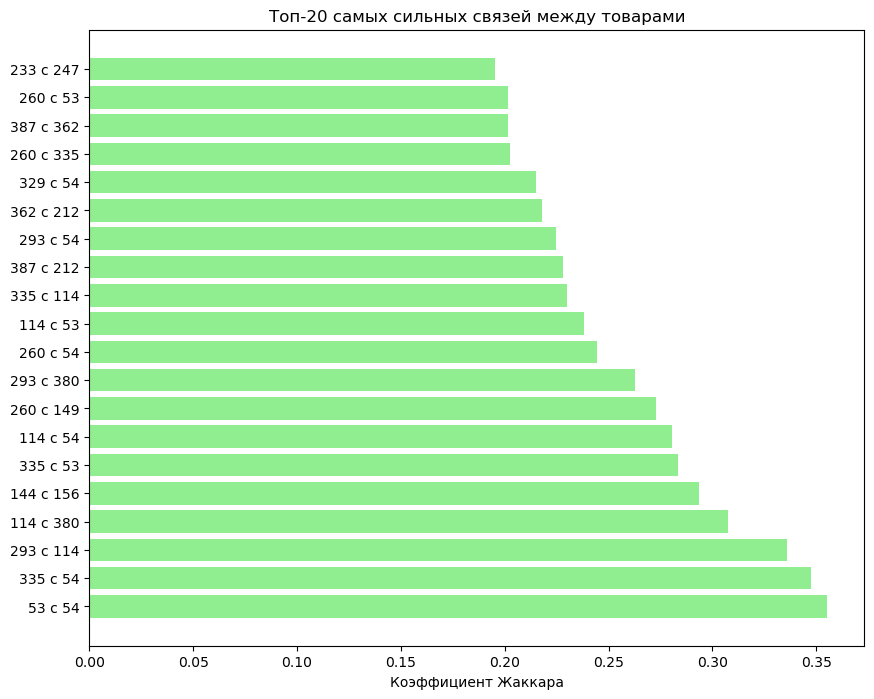

In [26]:
plt.figure(figsize=(10, 8))
plt.barh(range(len(top_pairs)), jaccard_values, color="lightgreen")
plt.yticks(range(len(top_pairs)), pairs_names)
plt.xlabel("Коэффициент Жаккара")
plt.title("Топ-20 самых сильных связей между товарами");

#### Вывод
Здесь узнаем, что наиболее сильная связь - 54 с 53. Этот раздел хорош тем, что показывает скрытые связи, которые не видны простому глазу.
Например - предмет 362 тесно связан с 212.

Анализируя эти данные, понимаю, какие товары будет выдавать рекомендательная модель чаще всего, например, после 54 - пойдет 53 с большей вероятностью.

## Анализ разнообразия сессий

На этом шаге я выясняю ответ на вопрос -
"А на сколько разнообразные предметы выбирает пользователь в ходе сессии?"

In [27]:
# Расчитываю коэффициент разнообразия - кол-во уникальных товаров / все товары в сессии
diversity = [len(set(session)) / len(session) for session in sessions]

mean_div = np.mean(diversity)
median_div = np.median(diversity)

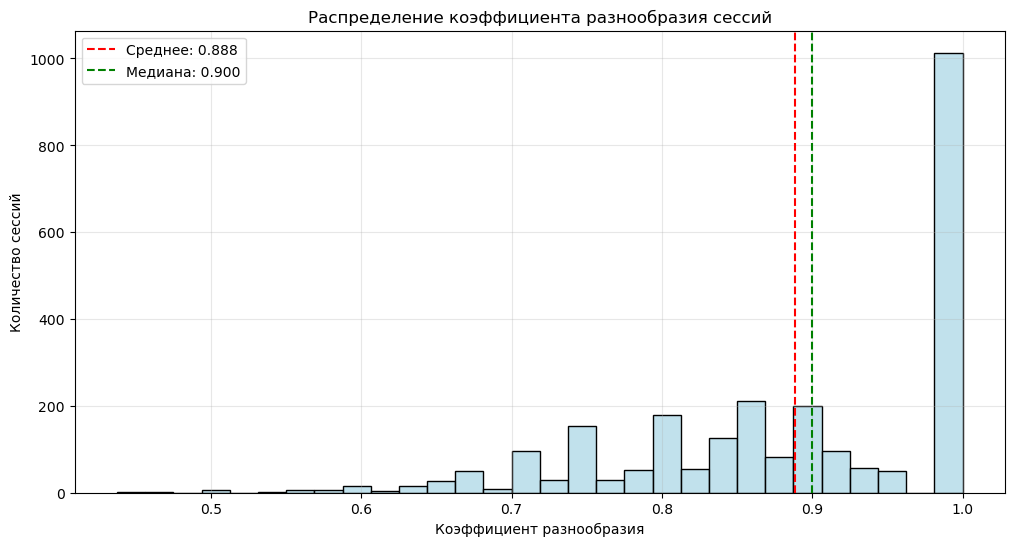

In [28]:
# Гистограмма по итогам вычисления
plt.figure(figsize=(12, 6))
sns.histplot(diversity, bins=30, color="lightblue")

plt.axvline(mean_div, color="red", linestyle='--', label=f"Среднее: {mean_div:.3f}")
plt.axvline(median_div, color="green", linestyle='--', label=f"Медиана: {median_div:.3f}")

plt.xlabel("Коэффициент разнообразия")
plt.ylabel("Количество сессий")
plt.title("Распределение коэффициента разнообразия сессий")
plt.legend()
plt.grid(alpha=0.3);

#### Вывод
Вывод - подавляющее большинство сессий - с уникальными товарами - пользователи выбирали разные товары и в итоге покупали товар, который до этого не видели чаще всего. Но это всего лишь около 1000 случаев. Соответсвенно - остальные ~1500 содержат повторы.

## Анализ распределения просмотров

Выясняю, как распределены просмотры товаров с помощью индекса Джини.

- Если индекс Джини высокий - значит малая часть товаров забрала себе большинство просмотров.
- Иначе - товары распределены примерно равномерно


In [29]:
def gini_index(values: list[int]) -> float:
    """Индекс Джини
    
    Parameters
    -------
        values: Список частот товаров
        
    Returns
    -------
        float: Значение индекса Джини от 0 до 1
    """
    sorted_values = np.sort(values)
    n = len(sorted_values)
    cumsum = np.cumsum(sorted_values)
    return (n + 1 - 2 * np.sum(cumsum) / cumsum[-1]) / n

In [30]:
# Собираю все просмотры
all_views = [item for session in sessions for item in session]
view_frequencies  = list(Counter(all_views).values())

# Собираю только финальные просмотры - покупки
purchases = [session[-1] for session in sessions if session]
purchase_frequencies = list(Counter(purchases).values())

# Считаю Джини
gini_views = gini_index(view_frequencies)
gini_purchases = gini_index(purchase_frequencies)

Индекс Джини просмотров:

In [31]:
print(f"Индекс Джини: {gini_views:.4f}")
print(f"Всего просмотров: {sum(view_frequencies)}")

Индекс Джини: 0.6705
Всего просмотров: 26843


Индекс Джини покупок:

In [32]:
print(f"Индекс Джини: {gini_purchases:.4f}")
print(f"Уникальных товаров в покупках: {len(purchase_frequencies)}")
print(f"Всего покупок: {sum(purchase_frequencies)}")

Индекс Джини: 0.6621
Уникальных товаров в покупках: 339
Всего покупок: 2565


#### Вывод
Небольшое количество предметов сконцентрировало большее число просмотров и покупок.

Поскольку коэфициенты почти не отличаются, то популярные товары, которые просматриваются чаще и покупаются, за исключением лишь некоторых редких предметов.

## Анализ самых коротких сессий

Поскольку минимальная длина сессии по условию задания - 3, то товар, который является последним был куплен после всего
двух просмотров, поэтому я могу назвать его - уверенным выбором. Ведь человек не думал долго и не искал другие товары,
купив товар почти сразу


In [33]:
# Нахожу сессии длины 3
last_items_length3 = Counter()

for session in sessions:
    if len(session) == 3:
        last_items_length3[session[-1]] += 1

# Преобразую в DataFrame
last_items_df = pd.DataFrame(
    last_items_length3.most_common(),
    columns=["item", "count"]
)

last_items_df = last_items_df.set_index("item")
last_items_sorted = last_items_df.sort_values("count", ascending=False)

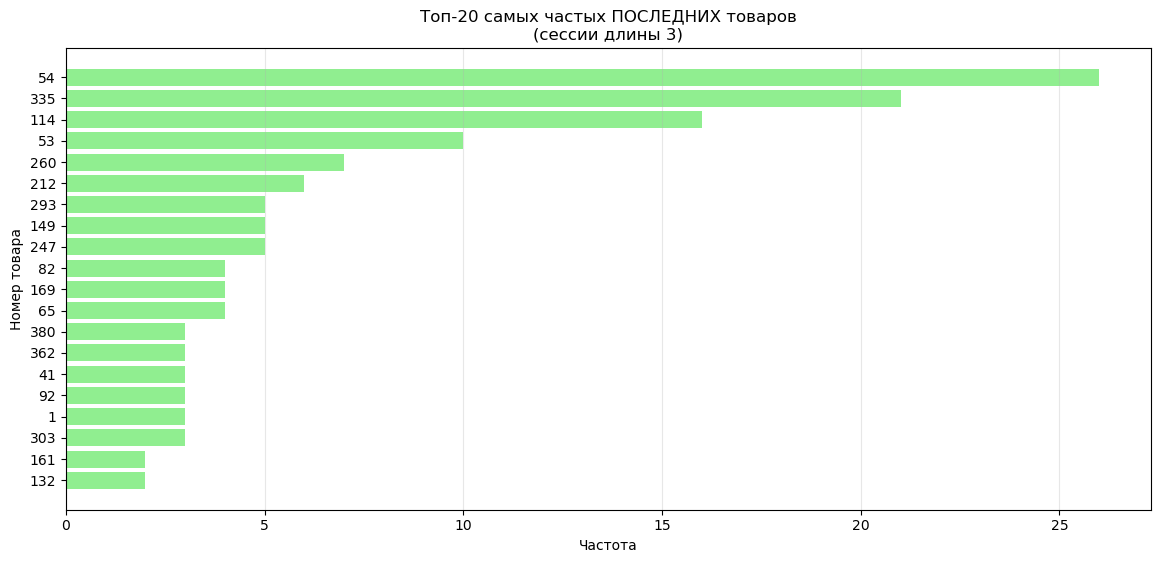

In [34]:
# Топ-20 самых частых последних товаров
top20_last = last_items_sorted.head(20)

# Создаю фигуру и оси правильно
fig, ax = plt.subplots(figsize=(14, 6))

# Топ-20 частых последних товаров
ax.barh(range(len(top20_last)), top20_last["count"], color="lightgreen")
ax.set_yticks(range(len(top20_last)))
ax.set_yticklabels(top20_last.index)
ax.set_title("Топ-20 самых частых ПОСЛЕДНИХ товаров\n(сессии длины 3)")
ax.set_xlabel("Частота")
ax.set_ylabel("Номер товара")
ax.invert_yaxis()
ax.grid(alpha=0.3, axis="x")

#### Вывод
Снова топ-5 товаров здесь повторяют распределение самых популярных. Эти товары убеждают людей выбрать их, просмотрев не так много других товаров.

## Последний график - анализирующий конверсию просмтров и покупок

В этом графике хочу понять, насколько товар вызывает уверенность. Насколько мало нужно просмотров в среднем, чтобы товар был куплен по итогу. Это покаызвает конверсия просмтров и покупок


In [35]:
# Собираю статистику по каждому товару
item_views = Counter()
item_purchases = Counter()

for session in sessions:
    for item in session:
        item_views[item] += 1
    if session:
        item_purchases[session[-1]] += 1

# Объединяб в DataFrame
conversion_data = []
all_items = set(item_views.keys()) | set(item_purchases.keys())

for item in all_items:
    views = item_views.get(item, 0)
    purchases = item_purchases.get(item, 0)
    conversion = (purchases / views * 100) if views > 0 else 0
    conversion_data.append({
        "item": item,
        "views": views,
        "purchases": purchases,
        "conversion": conversion
    })

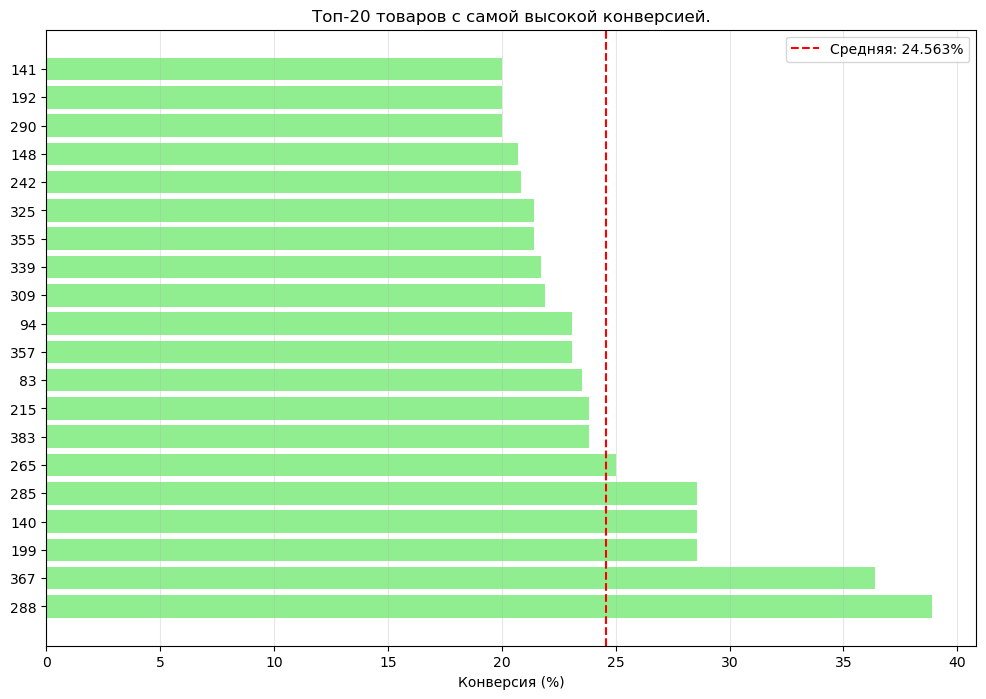

In [36]:
conversion_df = pd.DataFrame(conversion_data)

# Фильтрую товары с минимум 10 просмотрами и сортирую по конверсии, чтобы не было шумов
top_conversion = conversion_df[conversion_df["views"] >= 10].sort_values("conversion", ascending=False).head(20)

plt.figure(figsize=(12, 8))
plt.barh(range(len(top_conversion)), top_conversion["conversion"], color="lightgreen")
plt.yticks(range(len(top_conversion)), top_conversion["item"])
plt.xlabel("Конверсия (%)")
plt.title("Топ-20 товаров с самой высокой конверсией.")
plt.axvline(top_conversion["conversion"].mean(), color="red", linestyle='--', 
            label=f"Средняя: {top_conversion['conversion'].mean():.3f}%")
plt.legend()
plt.grid(alpha=0.3, axis="x");

#### Вывод
Вывод - товар с высочайшей конверсией - 288, видимо он так хорош, что вызывает больше уверенности, если человек его увидел.

6 товаров перешли отметку среднего.

Эти данные могли быть использованы в качестве рекомендаций тоже - но добавление их в топ-10 рекомендованных предметов не дает прироста качества модели.